# Comparing the simplest two shapes to detect differences by edge count distribution

In [32]:
#imports

import ecc_vr as vr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


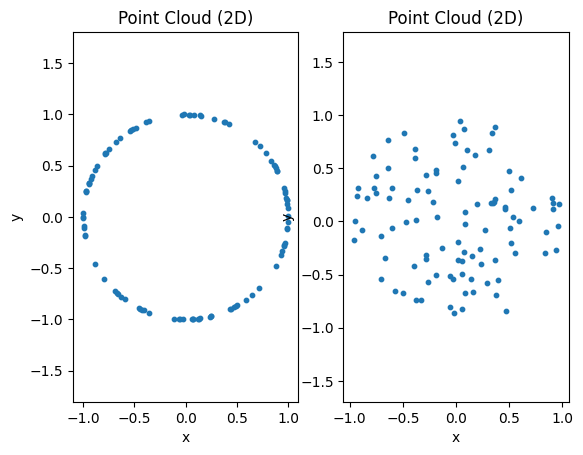

In [33]:
C = vr.sample_point_cloud(
    "circle",
    n_points = 100,
    ambient_dim= 2,
    seed = 123,
    circle_radius = 1
)

D = vr.sample_point_cloud(
    "disk",
    n_points = 100,
    ambient_dim= 2,
    seed = 123,
    circle_radius = 1
)

fig, ax = plt.subplots(1,2)

vr.plot_point_cloud_on_ax(ax[0], C, 2)
vr.plot_point_cloud_on_ax(ax[1], D, 2)



In [34]:
def edge_count_sim(
    shape: str,
    n_points: int,
    t: float,
    n_resamples: int,
    ambient_dim: int = 2,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        X = vr.sample_point_cloud(
            shape=shape,
            n_points=n_points,
            ambient_dim=ambient_dim,
            seed=sample_seed,
        )

        edge_counts[i] = vr.count_edges(X, t=t)

    return edge_counts


In [35]:
circle_counts = edge_count_sim(
    shape="circle",
    n_points=100,
    t=1.5,
    n_resamples=500,
    seed=42,
)

disk_counts = edge_count_sim(
    shape="disk",
    n_points=100,
    t=1.5,
    n_resamples=500,
    seed=43,
)


In [36]:
# standardizing distributions

def standarize(X):
    s = X.std(ddof=1)
    if s == 0:
        return np.zeros_like(X)
    return (X - X.mean()) / s

C_z = standarize(circle_counts)
D_z = standarize(disk_counts)

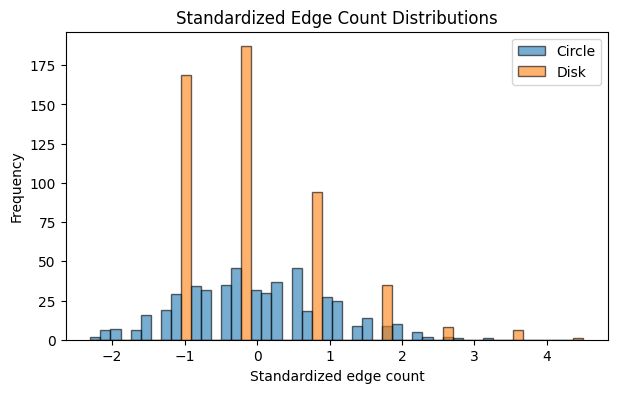

In [37]:
#histogram

bins = np.linspace(
    min(C_z.min(), D_z.min()),
    max(C_z.max(),D_z.max()),
)


plt.figure(figsize=(7, 4))
plt.hist(C_z, bins=bins, alpha=0.6, edgecolor="black", label="Circle")
plt.hist(D_z, bins=bins, alpha=0.6, edgecolor="black", label="Disk")
plt.xlabel("Standardized edge count")
plt.ylabel("Frequency")
plt.title("Standardized Edge Count Distributions")
plt.legend()
plt.show()

In [38]:
def sample_edge_count_curve(
        shape: str,
        n_points: int,
        t_grid: np.ndarray,
        ambient_dim: int = 2,
        seed: int | None = None,
) -> np.ndarray:
    
    X = vr.sample_point_cloud(
        shape = shape,
        n_points = n_points,
        ambient_dim = ambient_dim,
        seed = seed,
    )

    return np.array([vr.count_edges(X, t=float(t)) for t in t_grid], dtype = float)

def simulate_edge_count_curves(
    shape: str,
    n_points: int,
    t_grid: np.ndarray,
    n_resamples: int,
    ambient_dim: int = 2,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    curves = np.empty((n_resamples, len(t_grid)), dtype=float)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))
        curves[i] = sample_edge_count_curve(
            shape=shape,
            n_points=n_points,
            t_grid=t_grid,
            ambient_dim=ambient_dim,
            seed=sample_seed,
        )

    return curves

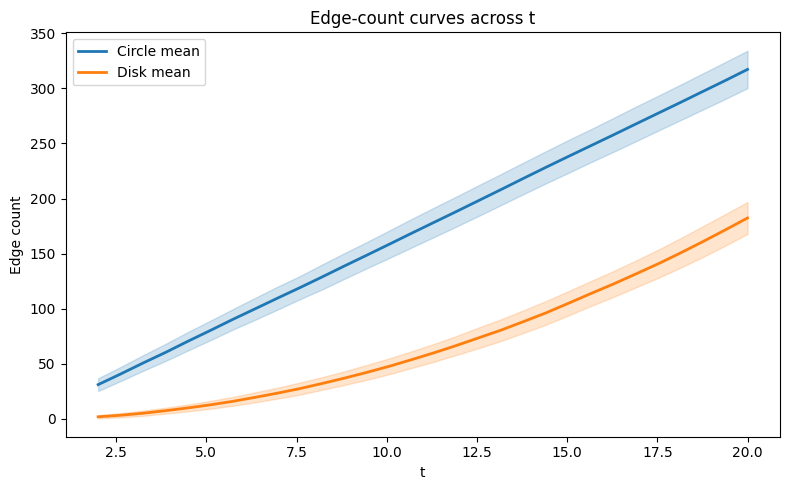

In [39]:
n_points = 100
n_resamples = 300
t_grid = np.linspace(2, 20, 30)

circle_curves = simulate_edge_count_curves(
    shape="circle",
    n_points=n_points,
    t_grid=t_grid,
    n_resamples=n_resamples,
    seed=42,
)

disk_curves = simulate_edge_count_curves(
    shape="disk",
    n_points=n_points,
    t_grid=t_grid,
    n_resamples=n_resamples,
    seed=43,
)

circle_mean = circle_curves.mean(axis=0)
circle_sd = circle_curves.std(axis=0, ddof=1)

disk_mean = disk_curves.mean(axis=0)
disk_sd = disk_curves.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_grid, circle_mean, color="tab:blue", lw=2, label="Circle mean")
ax.fill_between(
    t_grid,
    circle_mean - circle_sd,
    circle_mean + circle_sd,
    color="tab:blue",
    alpha=0.2,
)

ax.plot(t_grid, disk_mean, color="tab:orange", lw=2, label="Disk mean")
ax.fill_between(
    t_grid,
    disk_mean - disk_sd,
    disk_mean + disk_sd,
    color="tab:orange",
    alpha=0.2,
)

ax.set_xlabel("t")
ax.set_ylabel("Edge count")
ax.set_title("Edge-count curves across t")
ax.legend()
plt.tight_layout()
plt.show()

Accuracy: 1.0
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00        75
        disk       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



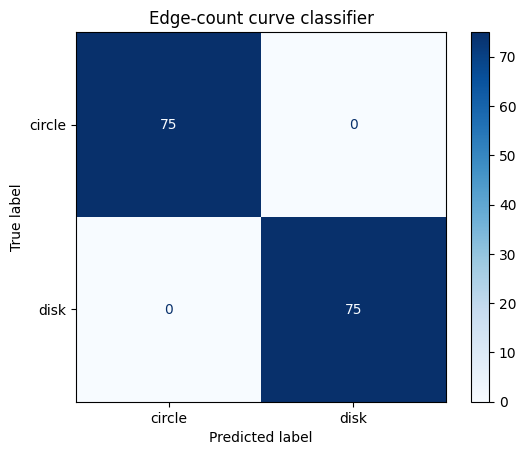

In [40]:
X = np.vstack([circle_curves, disk_curves]) #has shape (600,30) since there are 300 circle curves and 300 disk curves with each row one simulated edge count curve
y = np.array([0] * len(circle_curves) + [1] * len(disk_curves))  # 0=circle, 1=disk

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y #gives 450 training samples, 150 test samples with 75 circles and 75 disks in test set
)

clf = make_pipeline(
    StandardScaler(), #standardizes each feature column using training-set statistics
    LogisticRegression(max_iter=5000) #learns a linear decision boundary in 30-dimensional curve space
)

clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test) #train and predicts

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["circle", "disk"]))

ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=["circle", "disk"], cmap="Blues"
)
plt.title("Edge-count curve classifier")
plt.show()
